In [1]:
import gzip
import seaborn as sns
import sequence_tools as st
import numpy as np
import pandas as pd

A little background on the data: a defined number of sequences (~50-500) was sequenced using PacBio to obtain ~100,000 reads.  We want to identify the true amino acid sequences and remove any sequences resulting from sequencing errors.  To do this I will rank each unique sequence by its number of reads and take the $n$ most abundant sequences, where $n$ is the known number of input sequences.

In [2]:
# parent sequence used for epPCR (I obtained from Christian's pET vector fasta)
WT = st.translate('ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCAGAACATATGACCATTGCAGCAGCAATTCATGCACTGGATGCAGATGAAGCAGATGCAATTGTTATGGATATTGTTCCGGATGGTGAACGTGATGCATGGTGGGATGATGAAGGTTTTAGCAGCAGCCCGTTTACCAAAGATGCACATCATGCAGGAGTTGTTGCAACCAGCGTTACCCTGGGTCAGCTGCAGCGTGAACAGGGTGATAAACTGGTTAGCAAAGCAGCAGAATATTTTGGTATTGCCTGCCGTGTTAATGATGGTCTGCGTACCACCCGTTTTGTTCGTCTGTTTAGTGATGCCCTGGATGCCAAACCGCTGACCATTGGTCATGATTATGAAGTTGAATTTCTGCTGGCAACCCGTCGTGTTTATGAACCGTTTGAAGCACCGTTTAACTTTGCACCGCATTGTGGCGATGTTAGCTATGGTCGTGATACCGTTAATTGGCCTCTGAAACATAGCTTTCCGCGTCAGCTGGGTGGTTTTCTGACCATTCAGGGTGCAGATAATGATGCCGGTATGGTTATGTGGGATAATCGTCCGGAAAGCCGTGCAGCGCTGGATGAAATGCATGCAGAATATCGTGAAACCGGTGCAATTGCCGCACTGGAACGTGCAGCCAAAATCATGCTGAAACCGCAGCCTGGCCAGCTGACACTGTTTCAGAGCAAAAATCTGCATGCCATTGAACGTTGTACCAGCACCCGTCGTACCATGGGTCTGTTTCTGATTCATACCGAAGATGGTTGGCGTATGTTTGATTGA')

In [3]:
# load information about the 11 samples 
sample_info = pd.read_csv('sample_info.csv',header=0)
sample_info.columns = [c.strip() for c in sample_info.columns]
sample_info = sample_info.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
sample_info

,bin,activity,count,barcode,filename,simple activity,response
0,Bin1,(beta hidroxylation > parent),20,bc1036--bc1036,bc1036-no-indel.fa.gz,beta,3
1,Bin2,(beta hidroxylation ~ parent),54,bc1037--bc1037,bc1037-no-indel.fa.gz,beta,2
2,Bin3,(beta hidroxylation < parent),192,bc1038--bc1038,bc1038-no-indel.fa.gz,beta,1
3,Bin4,(no beta hidroxylation),694,bc1039--bc1039,bc1039-no-indel.fa.gz,beta,0
4,Bin5,(gamma hidroxylation > parent),240,bc1040--bc1040,bc1040-no-indel.fa.gz,gamma,2
5,Bin6,(gamma hidroxylation ~ parent),78,bc1030--bc1030,bc1030-no-indel.fa.gz,gamma,1
6,Bin7,(no gamma hidroxylation),642,bc1031--bc1031,bc1031-no-indel.fa.gz,gamma,0
7,Bin8,(azidation > parent),23,bc1032--bc1032,bc1032--bc1032-no-indel.fa.gz,azid,3
8,Bin9,(azidation ~ parent),54,bc1033--bc1033,bc1033--bc1033-no-indel.fa.gz,azid,2
9,Bin10,(azidation < parent),177,bc1034--bc1034,bc1034--bc1034-no-indel.fa.gz,azid,1


In [4]:
# some new fields we'll populate
sample_info['num reads'] = 0
sample_info['num unique'] = 0
sample_info['WT rank'] = 0
sample_info['WT percent'] = 0

In [5]:
def fasta2aaseq(filename):
    fasta = gzip.open(filename).read().decode("utf-8").strip().split('\n')
    dna_seq = fasta[1::2]
    AA_seq = [st.translate(s) for s in dna_seq]
    return AA_seq

def count_seqs(seq_list):
    seq_count = {}
    for seq in seq_list:
        if seq not in seq_count:
            seq_count[seq] = 1
        else:
            seq_count[seq] += 1  
   
    seqs_ranked_by_reads = sorted(seq_count.items(), key = lambda x: x[1], reverse=True)
    df = pd.DataFrame(seqs_ranked_by_reads,columns = ['sequence','count'])
    return df

def process_sample(row):
    nseq = sample_info['count'][row]
    response = sample_info['response'][row]    

    # load and count AA sequences 
    AA_seqs = fasta2aaseq(sample_info.filename[row])
    seq_count = count_seqs(AA_seqs)
      
    #update sample info
    sample_info.at[row,'num reads'] = len(AA_seqs)
    sample_info.at[row,'num unique'] = len(seq_count)

    # evaluate WT sequence 
    WTpres = sum(seq_count.sequence==WT)>0
    if WTpres:
        WTind = pd.Index(seq_count.sequence==WT).get_loc(True)
        WTpct = 100 * seq_count.iloc[WTind]['count']/sum(seq_count['count'])
        sample_info.at[row,'WT rank'] = WTind
        sample_info.at[row,'WT percent'] = WTpct
             
    # plot count curves on loglog and also include nseq
    sns.lineplot(x = np.log10(range(1,seq_count.shape[0]+1)),y = np.log10(seq_count['count']))
    if WTpres: sns.scatterplot(x = np.log10([WTind+1,WTind+1]),y = np.log10([seq_count['count'][WTind],seq_count['count'][WTind]]),marker='x',color='r')
    sns.lineplot(x = np.log10([nseq,nseq]),y = [0,np.log10(seq_count['count'][0])]);

    # update seq count to include a response and only include the top nseq
    seq_count['response'] = response
    seq_count = seq_count[:nseq]
    return seq_count

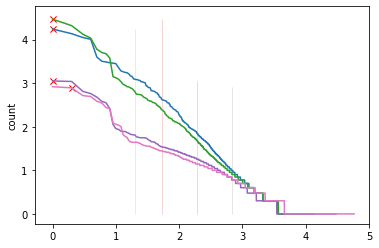

In [6]:
# beta hydroxylation
row = 0
beta = process_sample(row)

for row in range(1,4): 
    beta = beta.append(process_sample(row))

beta.to_pickle('beta_activity.pkl')

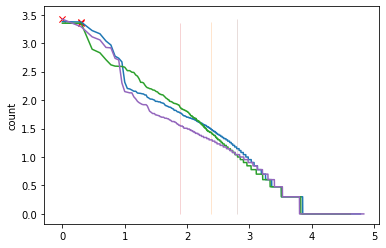

In [7]:
# gamma hydroxylation
row = 4
gamma = process_sample(row)

for row in range(5,7): 
    beta = gamma.append(process_sample(row))

gamma.to_pickle('gamma_activity.pkl')

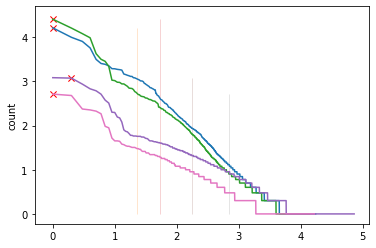

In [8]:
# azidation
row = 7
azid = process_sample(row)

for row in range(8,11): 
    azid = gamma.append(process_sample(row))

azid.to_pickle('azid_activity.pkl')

The counts/frequencies for each sequence shows a linear trend on the log-log plot.  What does this mean?  I belive these curves fall off faster than exponential. 

I expected to see some "kink" where we transition from true sequences to sequecing errors.  This may be weakly present in the data, but it's not very clear.

In [9]:
sample_info

,bin,activity,count,barcode,filename,simple activity,response,num reads,num unique,WT rank,WT percent
0,Bin1,(beta hidroxylation > parent),20,bc1036--bc1036,bc1036-no-indel.fa.gz,beta,3,168743,13522,0,10
1,Bin2,(beta hidroxylation ~ parent),54,bc1037--bc1037,bc1037-no-indel.fa.gz,beta,2,159322,12417,0,18
2,Bin3,(beta hidroxylation < parent),192,bc1038--bc1038,bc1038-no-indel.fa.gz,beta,1,49790,29914,0,2
3,Bin4,(no beta hidroxylation),694,bc1039--bc1039,bc1039-no-indel.fa.gz,beta,0,77468,58086,1,1
4,Bin5,(gamma hidroxylation > parent),240,bc1040--bc1040,bc1040-no-indel.fa.gz,gamma,2,107473,60120,1,2
5,Bin6,(gamma hidroxylation ~ parent),78,bc1030--bc1030,bc1030-no-indel.fa.gz,gamma,1,84390,41407,1,2
6,Bin7,(no gamma hidroxylation),642,bc1031--bc1031,bc1031-no-indel.fa.gz,gamma,0,105610,68062,0,2
7,Bin8,(azidation > parent),23,bc1032--bc1032,bc1032--bc1032-no-indel.fa.gz,azid,3,159959,17411,0,10
8,Bin9,(azidation ~ parent),54,bc1033--bc1033,bc1033--bc1033-no-indel.fa.gz,azid,2,146202,13840,0,17
9,Bin10,(azidation < parent),177,bc1034--bc1034,bc1034--bc1034-no-indel.fa.gz,azid,1,101769,72886,1,1


It is a little concerning that WT is the most/second abundant sequence in all 11 samples, and constitutes ~10% for samples with activity greater than parent.  Could it have snuck through the screen?  Would only need 2 false positives out of 20 to get 10%.